# Used Car Price Prediction - Exploratory Data Analysis, Data Cleaning & Feature Engineering

## Objective

The objective of this notebook is to explore the Used Car Price Prediction dataset, identify data quality issues, perform data cleaning, engineer meaningful features, and prepare the dataset for future machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_csv("used_cars.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (4009, 12)
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [4]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [5]:
df.describe(include="object")

C:\Users\7K\AppData\Local\Temp\ipykernel_23304\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [6]:
df.tail()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


## Missing Values and Duplicate Records

In [7]:
# Missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

fuel_type      170
accident       113
clean_title    596
dtype: int64

In [8]:
# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 879


In [9]:
# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Numerical and Categorical Features

In [10]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['model_year'], dtype='str')

Categorical Features:
Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='str')


C:\Users\7K\AppData\Local\Temp\ipykernel_23304\171480370.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


## Unique Values in Categorical Features

In [11]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].nunique(), "unique values")


brand
57 unique values

model
1898 unique values

milage
2818 unique values

fuel_type
7 unique values

engine
1146 unique values

transmission
62 unique values

ext_col
319 unique values

int_col
156 unique values

accident
2 unique values

clean_title
1 unique values

price
1569 unique values


In [12]:
for col in categorical_features:
    print(f"\nTop values in {col}")
    print(df[col].value_counts().head())


Top values in brand
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Name: count, dtype: int64

Top values in model
model
M3 Base               30
F-150 XLT             24
Corvette Base         22
1500 Laramie          18
Model Y Long Range    17
Name: count, dtype: int64

Top values in milage
milage
110,000 mi.    16
45,000 mi.     15
120,000 mi.    13
55,000 mi.     13
54,000 mi.     12
Name: count, dtype: int64

Top values in fuel_type
fuel_type
Gasoline         3309
Hybrid            194
E85 Flex Fuel     139
Diesel            116
–                  45
Name: count, dtype: int64

Top values in engine
engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             47
–                                                        45
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    44
Name: count, dtype:

## Outlier Detection

In [13]:
numerical_features

Index(['model_year'], dtype='str')

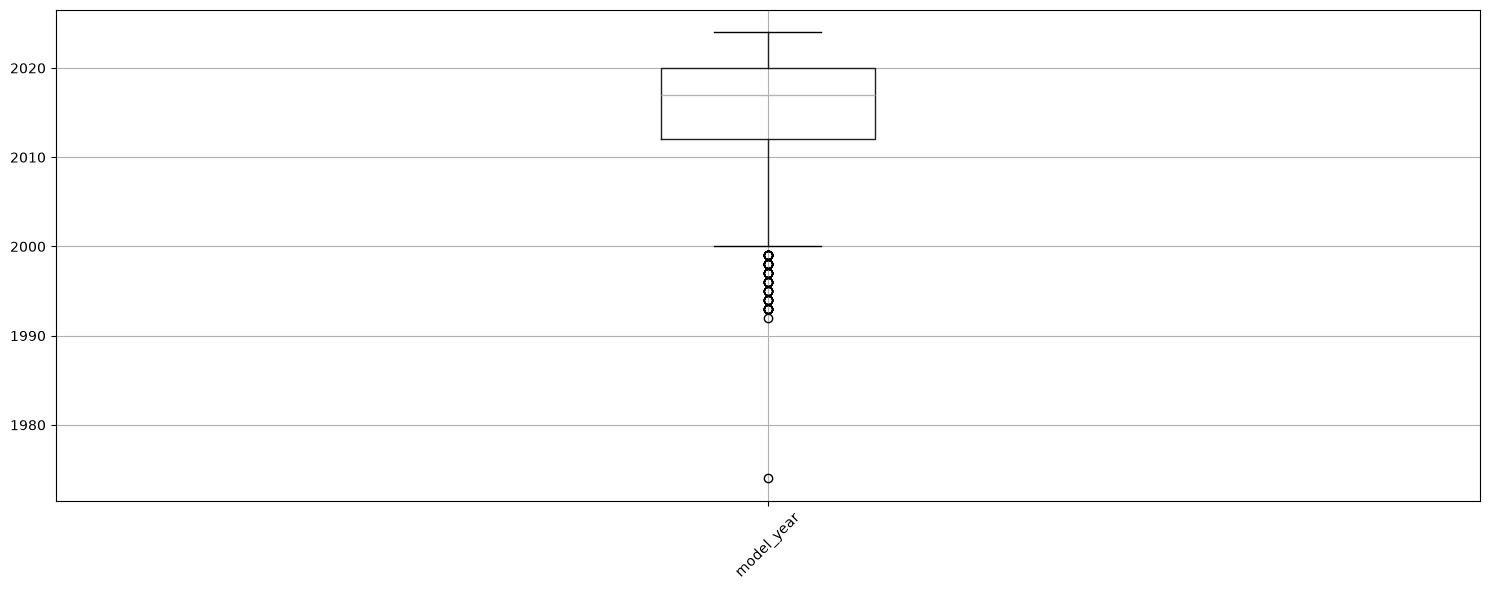

In [14]:
df[numerical_features].boxplot(figsize=(15,6), rot=45)
plt.tight_layout()
plt.show()

## Data Cleaning

In [16]:
# Fill missing numerical values
for col in numerical_features:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (4009, 12)


In [18]:
print("Remaining Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Remaining Missing Values:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

Duplicate Rows: 0


In [19]:
print(df.columns.tolist())

['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


## Feature Engineering

In [23]:
# Convert milage from text to numeric
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(int)
)

In [24]:
print(df["milage"].head())
print(df["milage"].dtype)

0    51000
1    34742
2    22372
3    88900
4     9835
Name: milage, dtype: int64
int64


In [20]:
# Feature 1: Car Age
current_year = 2026
df["Car_Age"] = current_year - df["model_year"]

In [25]:
# Feature 2: Mileage Per Year
df["Mileage_Per_Year"] = df["milage"] / (df["Car_Age"] + 1)

In [26]:
# Feature 3: Luxury Brand Indicator
luxury_brands = [
    "BMW", "Mercedes-Benz", "Audi", "Lexus",
    "Porsche", "Jaguar", "Land Rover",
    "Bentley", "Rolls-Royce", "Ferrari",
    "Lamborghini", "Maserati"
]

df["Is_Luxury_Brand"] = df["brand"].isin(luxury_brands).astype(int)

In [27]:
# Feature 4: High Mileage Indicator
median_mileage = df["milage"].median()

df["High_Mileage"] = (df["milage"] > median_mileage).astype(int)

In [28]:
# Feature 5: High Performance Engine
df["High_Performance"] = (
    df["engine"]
    .astype(str)
    .str.contains("V8|V10|V12", case=False, na=False)
    .astype(int)
)

## Preview Engineered Features

In [29]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Car_Age,Mileage_Per_Year,Is_Luxury_Brand,High_Mileage,High_Performance
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300",13,3642.857143,0,0,0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005",5,5790.333333,0,0,0
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Yes,"$54,598",4,4474.400000,1,0,0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500",11,7408.333333,0,1,0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,"$34,999",5,1639.166667,1,0,0


## Save the Cleaned Dataset

In [30]:
df.to_csv("cleaned_used_cars.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Verify the Cleaned Dataset

In [31]:
print("Dataset Shape:", df.shape)
print()

print("Missing Values:")
print(df.isnull().sum())

print()

print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (4009, 17)

Missing Values:
brand               0
model               0
model_year          0
milage              0
fuel_type           0
engine              0
transmission        0
ext_col             0
int_col             0
accident            0
clean_title         0
price               0
Car_Age             0
Mileage_Per_Year    0
Is_Luxury_Brand     0
High_Mileage        0
High_Performance    0
dtype: int64

Duplicate Rows: 0


## Preview Engineered Features

In [32]:
df[[
    "Car_Age",
    "Mileage_Per_Year",
    "Is_Luxury_Brand",
    "High_Mileage",
    "High_Performance"
]].head()

,Car_Age,Mileage_Per_Year,Is_Luxury_Brand,High_Mileage,High_Performance
0,13,3642.857143,0,0,0
1,5,5790.333333,0,0,0
2,4,4474.400000,1,0,0
3,11,7408.333333,0,1,0
4,5,1639.166667,1,0,0


## Key Insights

1. The dataset contains both numerical and categorical features, requiring preprocessing before machine learning.

2. Missing values and duplicate records were successfully handled to improve data quality.

3. Converting mileage to a numeric format enabled meaningful feature engineering and future analysis.

4. New features such as Car Age, Mileage Per Year, Luxury Brand Indicator, High Mileage Indicator, and High Performance Engine provide additional predictive information for price estimation.

5. The cleaned dataset is now suitable for building machine learning models for used car price prediction.